# NYT AI Comment Sentiment Analysis

Analyzes the ratio of positive vs. negative sentiment toward AI in NYT article comments over time.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load sentiment data
with open("data/sentiment.json") as f:
    articles = json.load(f)

# Flatten into a DataFrame
rows = []
for article in articles:
    for comment in article["comments"]:
        if "sentiment" in comment:
            rows.append({
                "month": article["month"],
                "headline": article["headline"],
                "commentID": comment["commentID"],
                "sentiment": comment["sentiment"],
                "confidence": comment.get("confidence", "unknown"),
                "recommendations": comment.get("recommendations", 0),
            })

df = pd.DataFrame(rows)
df["month"] = pd.to_datetime(df["month"] + "-01")
print(f"Total classified comments: {len(df)}")
df["sentiment"].value_counts()

Total classified comments: 138066


sentiment
negative      70004
neutral       29009
irrelevant    24466
positive      14587
Name: count, dtype: int64

In [2]:
# Monthly sentiment counts
monthly = df.groupby(["month", "sentiment"]).size().unstack(fill_value=0)

# Ensure all three columns exist
for col in ["positive", "negative", "neutral"]:
    if col not in monthly.columns:
        monthly[col] = 0

monthly["total"] = monthly.sum(axis=1)
monthly["pct_positive"] = monthly["positive"] / monthly["total"] * 100
monthly["pct_negative"] = monthly["negative"] / monthly["total"] * 100
monthly["pct_neutral"] = monthly["neutral"] / monthly["total"] * 100

monthly.head()

sentiment,irrelevant,negative,neutral,positive,total,pct_positive,pct_negative,pct_neutral
month,,,,,,,,
2022-11-01,74,219,100,62,455,13.626374,48.131868,21.978022
2022-12-01,165,255,141,46,607,7.578254,42.009885,23.228995
2023-01-01,879,2382,1341,624,5226,11.940299,45.579793,25.660161
2023-02-01,327,1830,892,271,3320,8.162651,55.120482,26.867470
2023-03-01,447,1887,1555,892,4781,18.657185,39.468730,32.524576


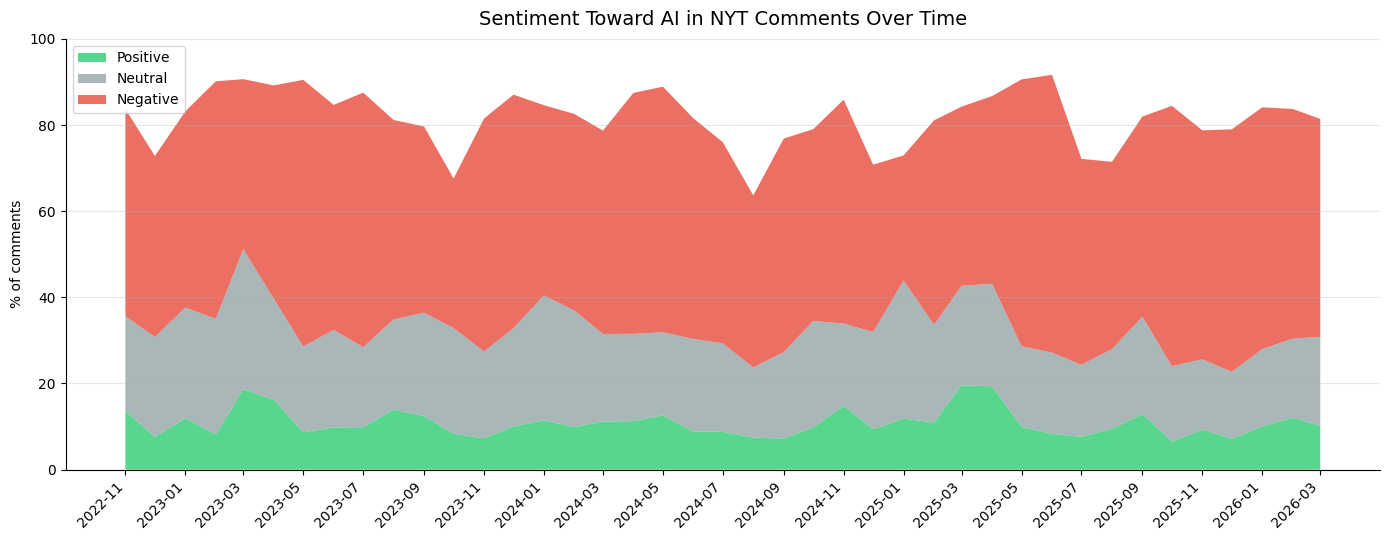

In [3]:
# Stacked area chart: sentiment ratio over time
fig, ax = plt.subplots(figsize=(14, 5.5))

ax.stackplot(
    monthly.index,
    monthly["pct_positive"],
    monthly["pct_neutral"],
    monthly["pct_negative"],
    labels=["Positive", "Neutral", "Negative"],
    colors=["#2ecc71", "#95a5a6", "#e74c3c"],
    alpha=0.8,
)

ax.set_title("Sentiment Toward AI in NYT Comments Over Time", fontsize=14, pad=10)
ax.set_ylabel("% of comments")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

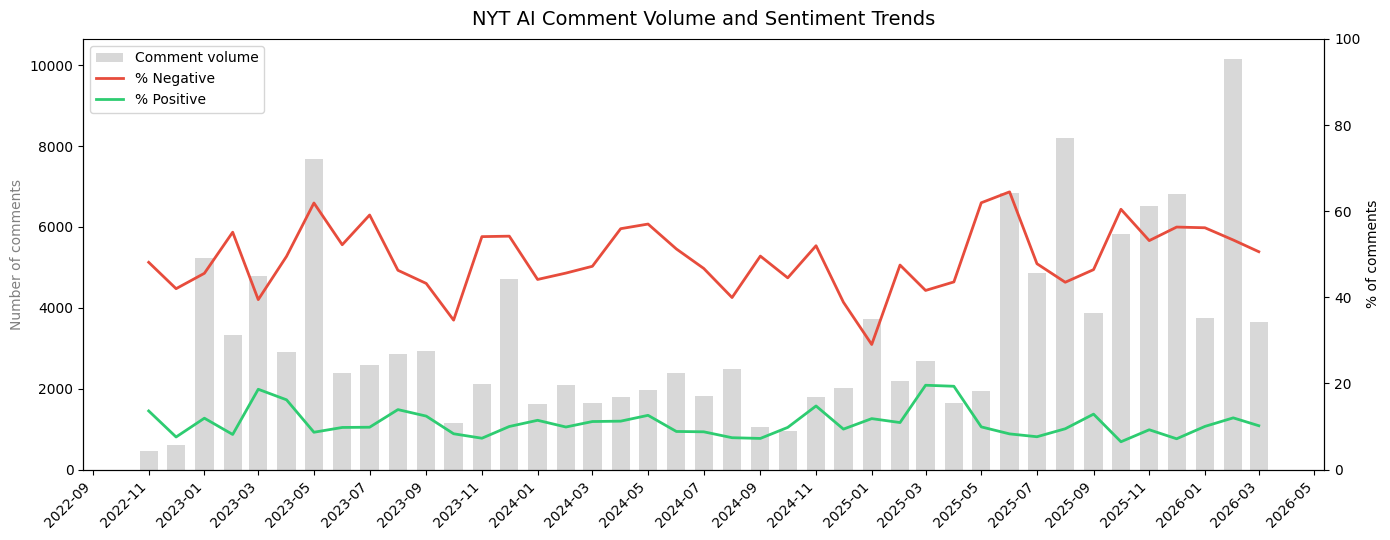

In [4]:
# Comment volume + sentiment lines
fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.bar(monthly.index, monthly["total"], width=20, alpha=0.3, color="gray", label="Comment volume")
ax1.set_ylabel("Number of comments", color="gray")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["pct_negative"], color="#e74c3c", linewidth=2, label="% Negative")
ax2.plot(monthly.index, monthly["pct_positive"], color="#2ecc71", linewidth=2, label="% Positive")
ax2.set_ylabel("% of comments")
ax2.set_ylim(0, 100)

ax1.set_title("NYT AI Comment Volume and Sentiment Trends", fontsize=14, pad=10)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.spines["top"].set_visible(False)
fig.tight_layout()
plt.show()

## Tool vs. Entity Framing

How do people conceptualize AI — as a tool humans control, or as an autonomous agent with its own agency? This section tracks the "tool" vs. "entity" framing ratio over time, and explores how framing interacts with sentiment.

In [5]:
# Build framing dataframe (exclude "neither" and unclassified)
framing_rows = []
for article in articles:
    for comment in article["comments"]:
        if comment.get("framing") in ("tool", "entity"):
            framing_rows.append({
                "month": article["month"],
                "framing": comment["framing"],
                "sentiment": comment.get("sentiment", ""),
                "confidence": comment.get("confidence", ""),
            })

df_framing = pd.DataFrame(framing_rows)
df_framing["month"] = pd.to_datetime(df_framing["month"] + "-01")
print(f"Comments with tool/entity framing: {len(df_framing)}")
df_framing["framing"].value_counts()

Comments with tool/entity framing: 93203


framing
tool      66437
entity    26766
Name: count, dtype: int64

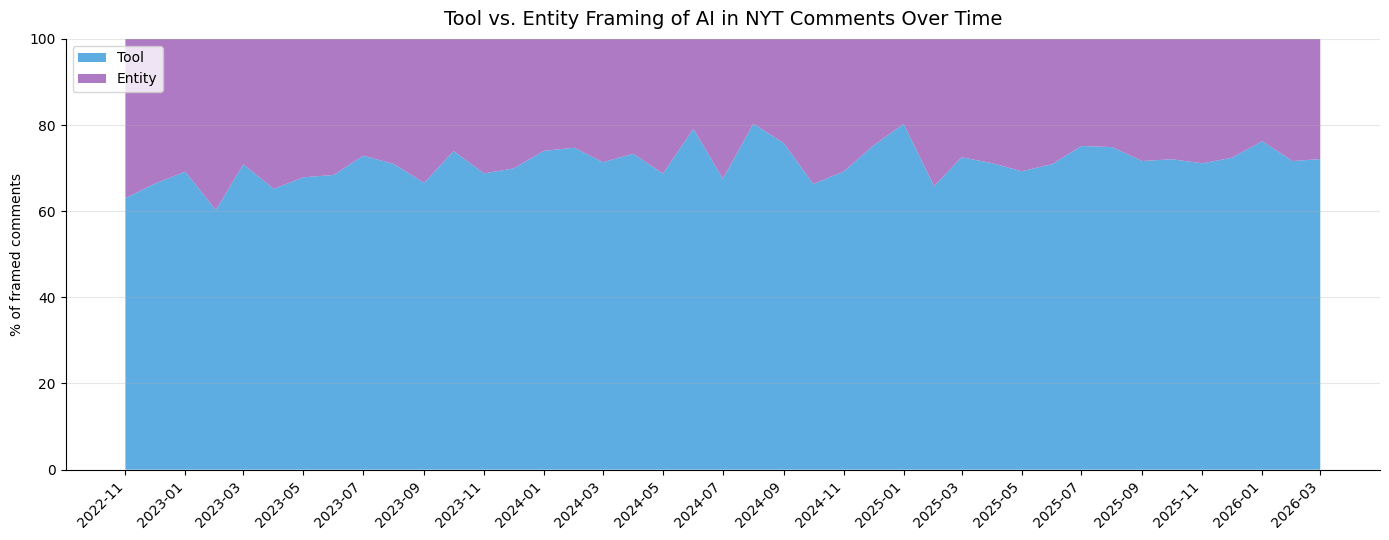

In [6]:
# Tool vs Entity ratio over time
monthly_framing = df_framing.groupby(["month", "framing"]).size().unstack(fill_value=0)
monthly_framing["total"] = monthly_framing.sum(axis=1)
monthly_framing["pct_tool"] = monthly_framing["tool"] / monthly_framing["total"] * 100
monthly_framing["pct_entity"] = monthly_framing["entity"] / monthly_framing["total"] * 100

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.stackplot(
    monthly_framing.index,
    monthly_framing["pct_tool"],
    monthly_framing["pct_entity"],
    labels=["Tool", "Entity"],
    colors=["#3498db", "#9b59b6"],
    alpha=0.8,
)

ax.set_title("Tool vs. Entity Framing of AI in NYT Comments Over Time", fontsize=14, pad=10)
ax.set_ylabel("% of framed comments")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

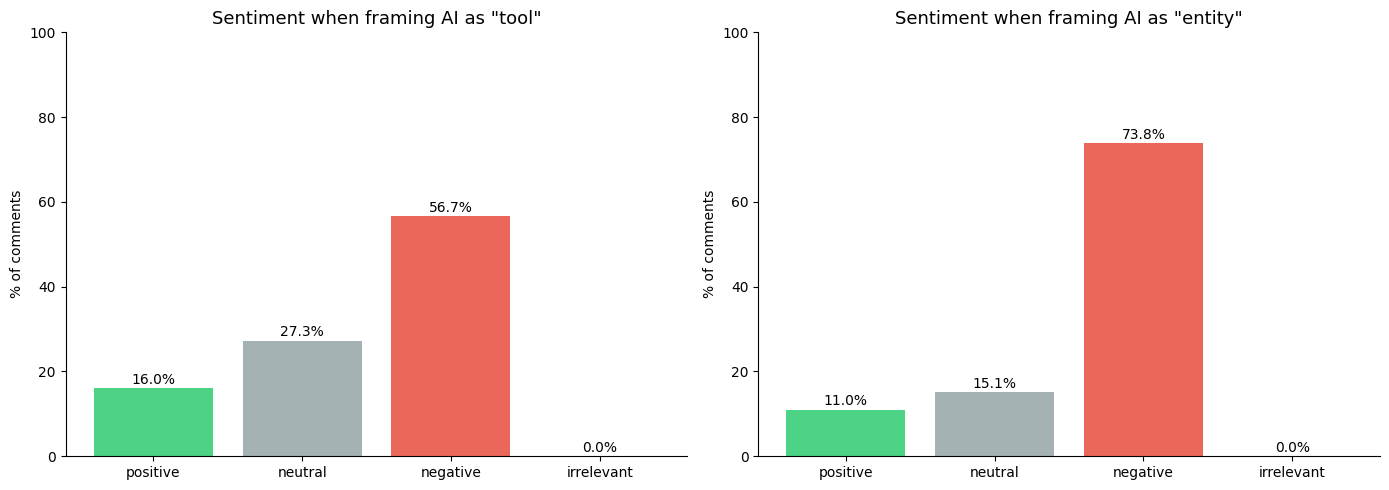

In [7]:
# Sentiment breakdown within each framing type
framing_sentiment = df_framing.groupby(["framing", "sentiment"]).size().unstack(fill_value=0)
framing_sentiment_pct = framing_sentiment.div(framing_sentiment.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, framing in zip(axes, ["tool", "entity"]):
    if framing not in framing_sentiment_pct.index:
        continue
    row = framing_sentiment_pct.loc[framing]
    colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c", "irrelevant": "#f39c12"}
    vals = [row.get(s, 0) for s in colors]
    ax.bar(list(colors.keys()), vals, color=list(colors.values()), alpha=0.85)
    ax.set_title(f'Sentiment when framing AI as "{framing}"', fontsize=13)
    ax.set_ylabel("% of comments")
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for i, v in enumerate(vals):
        ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

fig.tight_layout()
plt.show()